# DMG: Doubly Mild Generalization for Offline Reinforcement Learning
## NED University of Engineering & Technology — CT-469 Reinforcement Learning

**Paper:** Mao et al., NeurIPS 2024 · [arXiv:2411.07934](https://arxiv.org/abs/2411.07934)  
**Environment:** `halfcheetah-medium-v2` (D4RL benchmark)  
**Stack:** Python 3.12 · PyTorch · gymnasium · mujoco (modern bindings)

---



## ▶ Cell 1 — Installation



In [ ]:
# ================================================================
# CELL 1: Install all dependencies — Python 3.12 native.
# ================================================================

import subprocess, sys

packages = [
    # MuJoCo: official DeepMind Python bindings (Python 3.12 native)
    "mujoco>=3.1.0",
    # Gymnasium: maintained successor to OpenAI gym
    "gymnasium[mujoco]>=0.29.0",
    # Data loading
    "h5py>=3.9.0",
    # Plotting
    "matplotlib>=3.7.0",
    "seaborn>=0.12.0",
    # Progress bars
    "tqdm",
]

print("Installing packages...")
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "--quiet", "--upgrade"] + packages,
    capture_output=True, text=True
)
if result.returncode != 0:
    print("STDERR:", result.stderr[-2000:])
else:
    print("All packages installed successfully.")
    print("\n" + "="*60)
    print("="*60)

Installing packages...
All packages installed successfully.

ACTION REQUIRED: Runtime → Restart session
Then continue from Cell 2.


## ▶ Cell 2 — Verify Environment
*(Run after restarting the session)*

In [ ]:
# ================================================================
# CELL 2: Verify all imports work cleanly on Python 3.12.
# ================================================================
import sys
print(f"Python: {sys.version}")

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

import numpy as np
print(f"NumPy: {np.__version__}")

import mujoco
print(f"MuJoCo: {mujoco.__version__}")

import gymnasium as gym
print(f"Gymnasium: {gym.__version__}")

import h5py
print(f"h5py: {h5py.__version__}")

print("\n✓ All imports successful. No legacy packages required.")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
NumPy: 2.0.2
MuJoCo: 3.7.0
Gymnasium: 1.2.3
h5py: 3.16.0

✓ All imports successful. No legacy packages required.


## ▶ Cell 3 — Download D4RL Dataset (No `d4rl` Package Needed)

D4RL datasets are plain HDF5 files. We download directly from the source.
This completely bypasses the broken `d4rl` Python package.

In [ ]:
# ================================================================
# CELL 3: Download D4RL HDF5 dataset directly.
# No d4rl package. No gym==0.23.1. Just wget + h5py.
# ================================================================
import os
import urllib.request
import h5py
import numpy as np

DATASET_URL = (
    "http://rail.eecs.berkeley.edu/datasets/offline_rl/"
    "gym_mujoco_v2/halfcheetah_medium-v2.hdf5"
)
DATASET_PATH = "/content/halfcheetah_medium_v2.hdf5"

if not os.path.exists(DATASET_PATH):
    print(f"Downloading dataset from RAIL lab...")
    print(f"URL: {DATASET_URL}")

    def _progress(block_num, block_size, total_size):
        pct = min(block_num * block_size / total_size * 100, 100)
        if block_num % 200 == 0:
            print(f"  {pct:.0f}%", end="\r")

    urllib.request.urlretrieve(DATASET_URL, DATASET_PATH, _progress)
    print(f"Download complete. File size: {os.path.getsize(DATASET_PATH)/1e6:.1f} MB")
else:
    print(f"Dataset already exists: {DATASET_PATH}")


def load_d4rl_hdf5(path: str) -> dict:
    """Load D4RL dataset from HDF5 file into a numpy dict.

    Returns dict with keys:
        observations, actions, rewards, next_observations, terminals
    """
    with h5py.File(path, 'r') as f:
        dataset = {
            'observations':      np.array(f['observations'],      dtype=np.float32),
            'actions':           np.array(f['actions'],           dtype=np.float32),
            'rewards':           np.array(f['rewards'],           dtype=np.float32),
            'next_observations': np.array(f['next_observations'], dtype=np.float32),
            'terminals':         np.array(f['terminals'],         dtype=np.float32),
        }
    return dataset


dataset = load_d4rl_hdf5(DATASET_PATH)

N = dataset['observations'].shape[0]
STATE_DIM  = dataset['observations'].shape[1]
ACTION_DIM = dataset['actions'].shape[1]

print(f"\nDataset loaded successfully:")
print(f"  Transitions : {N:,}")
print(f"  State dim   : {STATE_DIM}")
print(f"  Action dim  : {ACTION_DIM}")
print(f"  Reward range: [{dataset['rewards'].min():.2f}, {dataset['rewards'].max():.2f}]")
print(f"  Action range: [{dataset['actions'].min():.2f}, {dataset['actions'].max():.2f}]")

URL: http://rail.eecs.berkeley.edu/datasets/offline_rl/gym_mujoco_v2/halfcheetah_medium-v2.hdf5
Download complete. File size: 237.7 MB

Dataset loaded successfully:
  Transitions : 1,000,000
  State dim   : 17
  Action dim  : 6
  Reward range: [-2.84, 8.33]
  Action range: [-1.00, 1.00]


## ▶ Cell 4 — Complete DMG Implementation

Self-contained implementation of all DMG components with type hints and docstrings.
No external dependencies beyond PyTorch.

In [ ]:
# ================================================================
# CELL 4: Complete DMG Implementation
#
# Components:
#   MLP                 - Generic feedforward network
#   ValueNetwork        - V(s) via expectile regression
#   TwinQNetwork        - Double Q(s,a) for clipped double Q
#   SinusoidalTimeEmbed - DDPM timestep embedding
#   ScoreNetwork        - epsilon_theta(a_t, s, t)
#   GaussianDiffusion   - DDPM forward / reverse process
#   OfflineBuffer       - Offline D4RL replay buffer
#   DMGAgent            - Full algorithm: V + Q + Actor updates
# ================================================================

import math
import time
from copy    import deepcopy
from typing  import Dict, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass


# ------------------------------------------------------------------
# 1.  MLP
# ------------------------------------------------------------------

class MLP(nn.Module):
    """Generic multi-layer perceptron with configurable depth and activation.

    Args:
        input_dim:    Input feature dimensionality.
        output_dim:   Output feature dimensionality.
        hidden_dims:  List of hidden layer widths.
        activation:   Activation class applied after each hidden layer.
    """
    def __init__(
        self,
        input_dim:   int,
        output_dim:  int,
        hidden_dims: List[int],
        activation:  type = nn.ReLU,
    ) -> None:
        super().__init__()
        layers: List[nn.Module] = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), activation()]
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# ------------------------------------------------------------------
# 2.  Value Network  V(s)
# ------------------------------------------------------------------

class ValueNetwork(nn.Module):
    """State-value function V(s) trained with expectile regression.

    V(s) converges to the τ-quantile of {Q(s,a) : a in dataset},
    providing a safe, in-sample upper bound on action values.

    Args:
        state_dim:  Dimensionality of the observation space.
        hidden_dim: Width of each hidden layer (paper: 256).
        n_hidden:   Number of hidden layers (paper: 3).
    """
    def __init__(self, state_dim: int, hidden_dim: int = 256, n_hidden: int = 3):
        super().__init__()
        self.net = MLP(state_dim, 1, [hidden_dim] * n_hidden)

    def forward(self, state: torch.Tensor) -> torch.Tensor:
        """Returns V(s) of shape (batch,)."""
        return self.net(state).squeeze(-1)


# ------------------------------------------------------------------
# 3.  Twin Q-Network  Q(s, a)
# ------------------------------------------------------------------

class TwinQNetwork(nn.Module):
    """Double Q-network to reduce overestimation bias (Fujimoto et al., 2018).

    Maintains two independent Q-heads; training uses both,
    inference uses min(Q1, Q2) for conservative evaluation.

    Args:
        state_dim:  Dimensionality of the observation space.
        action_dim: Dimensionality of the action space.
        hidden_dim: Width of each hidden layer.
        n_hidden:   Number of hidden layers.
    """
    def __init__(self, state_dim: int, action_dim: int,
                 hidden_dim: int = 256, n_hidden: int = 3):
        super().__init__()
        inp = state_dim + action_dim
        dims = [hidden_dim] * n_hidden
        self.q1 = MLP(inp, 1, dims)
        self.q2 = MLP(inp, 1, dims)

    def both(self, state: torch.Tensor, action: torch.Tensor
             ) -> Tuple[torch.Tensor, torch.Tensor]:
        """Returns (Q1(s,a), Q2(s,a)) each of shape (batch,)."""
        x = torch.cat([state, action], dim=-1)
        return self.q1(x).squeeze(-1), self.q2(x).squeeze(-1)

    def forward(self, state: torch.Tensor, action: torch.Tensor) -> torch.Tensor:
        """Returns min(Q1, Q2) of shape (batch,)."""
        return torch.min(*self.both(state, action))


# ------------------------------------------------------------------
# 4.  Sinusoidal Time Embedding  (DDPM)
# ------------------------------------------------------------------

class SinusoidalTimeEmbed(nn.Module):
    """Maps integer diffusion timestep t to a dense embedding.

    Uses sinusoidal encoding (Vaswani et al., 2017) followed by
    a 2-layer SiLU MLP to produce a learnable time representation.

    Args:
        embed_dim: Output embedding dimensionality (paper: 128).
    """
    def __init__(self, embed_dim: int = 128):
        super().__init__()
        half = embed_dim // 2
        freqs = torch.exp(
            -math.log(10_000) * torch.arange(half, dtype=torch.float32) / half
        )
        self.register_buffer("freqs", freqs)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4), nn.SiLU(),
            nn.Linear(embed_dim * 4, embed_dim), nn.SiLU(),
        )

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        """Args:  t of shape (batch,) integer. Returns (batch, embed_dim)."""
        sinusoid = t.float().unsqueeze(-1) * self.freqs  # (B, half)
        emb = torch.cat([sinusoid.sin(), sinusoid.cos()], dim=-1)
        return self.mlp(emb)


# ------------------------------------------------------------------
# 5.  Diffusion Score Network  ε_θ(a_t, s, t)
# ------------------------------------------------------------------

class ScoreNetwork(nn.Module):
    """Noise-prediction network for the conditional DDPM policy.

    Given noisy action a_t, state conditioning s, and timestep t,
    predicts the noise ε that was added during the forward process.

    Architecture: [a_t, s, embed(t)] → 3-layer ReLU MLP → ε̂

    Args:
        state_dim:     Dimensionality of the state space.
        action_dim:    Dimensionality of the action space.
        hidden_dim:    Width of each hidden layer.
        time_embed_dim: Dimensionality of the sinusoidal time embedding.
        n_hidden:      Number of hidden layers.
    """
    def __init__(self, state_dim: int, action_dim: int,
                 hidden_dim: int = 256, time_embed_dim: int = 128,
                 n_hidden: int = 3):
        super().__init__()
        self.time_embed = SinusoidalTimeEmbed(time_embed_dim)
        inp = state_dim + action_dim + time_embed_dim
        self.net = MLP(inp, action_dim, [hidden_dim] * n_hidden)

    def forward(self, a_noisy: torch.Tensor, state: torch.Tensor,
                t: torch.Tensor) -> torch.Tensor:
        """Returns predicted noise ε̂ of shape (batch, action_dim)."""
        t_emb = self.time_embed(t)
        x = torch.cat([a_noisy, state, t_emb], dim=-1)
        return self.net(x)


# ------------------------------------------------------------------
# 6.  Gaussian Diffusion Process  (DDPM)
# ------------------------------------------------------------------

class GaussianDiffusion(nn.Module):
    """DDPM forward and reverse processes for action generation.

    Uses a linear beta schedule with T steps (paper uses T=5 for efficiency).

    Forward (noising):  q(a_t | a_0) = N(√ᾱ_t · a_0, (1-ᾱ_t) · I)
    Reverse (denoising): p_θ(a_{t-1} | a_t, s) parameterised by ScoreNetwork

    Args:
        score_net:   The ε_θ noise-prediction network.
        action_dim:  Dimensionality of the action space.
        T:           Number of diffusion steps.
        beta_start:  Starting β for the noise schedule.
        beta_end:    Ending β for the noise schedule.
        action_clip: Clamp sampled actions to [-clip, +clip].
    """
    def __init__(self, score_net: ScoreNetwork, action_dim: int,
                 T: int = 5, beta_start: float = 0.1, beta_end: float = 10.0,
                 action_clip: float = 1.0):
        super().__init__()
        self.score_net  = score_net
        self.action_dim = action_dim
        self.T          = T
        self.clip       = action_clip

        # Pre-compute noise schedule buffers
        betas    = torch.linspace(beta_start / T, beta_end / T, T).clamp(max=0.999)
        alphas   = 1.0 - betas
        alpha_bar      = torch.cumprod(alphas, dim=0)
        alpha_bar_prev = torch.cat([torch.ones(1), alpha_bar[:-1]])

        self.register_buffer("betas",         betas)
        self.register_buffer("alphas",        alphas)
        self.register_buffer("alpha_bar",     alpha_bar)
        self.register_buffer("alpha_bar_prev",alpha_bar_prev)
        self.register_buffer("sqrt_ab",       alpha_bar.sqrt())
        self.register_buffer("sqrt_1mab",     (1.0 - alpha_bar).sqrt())

    # ---- Forward process -------------------------------------------------

    def q_sample(self, a0: torch.Tensor, t: torch.Tensor,
                 noise: torch.Tensor) -> torch.Tensor:
        """Corrupt a0 to a_t:  a_t = √ᾱ_t·a0 + √(1-ᾱ_t)·ε"""
        sa  = self.sqrt_ab[t].unsqueeze(-1)     # (B,1)
        s1a = self.sqrt_1mab[t].unsqueeze(-1)   # (B,1)
        return sa * a0 + s1a * noise

    # ---- Training loss ---------------------------------------------------

    def loss(self, a0: torch.Tensor, state: torch.Tensor) -> torch.Tensor:
        """L_simple: MSE between true noise and predicted noise.

        L = E_{t, a0, ε}[ ‖ε - ε_θ(q_sample(a0,t,ε), s, t)‖² ]
        """
        B = a0.shape[0]
        t     = torch.randint(0, self.T, (B,), device=a0.device)
        noise = torch.randn_like(a0)
        a_t   = self.q_sample(a0, t, noise)
        pred  = self.score_net(a_t, state, t)
        return F.mse_loss(pred, noise)

    # ---- Reverse process (sampling) ---------------------------------------

    @torch.no_grad()
    def sample(self, state: torch.Tensor, n_samples: int = 1) -> torch.Tensor:
        """DDPM ancestral sampling: a_T → a_{T-1} → ... → a_0.

        Args:
            state:     Conditioning context of shape (batch, state_dim).
            n_samples: Number of candidate actions per state.

        Returns:
            Denoised actions of shape (batch * n_samples, action_dim).
        """
        B  = state.shape[0]
        # Repeat each state n_samples times
        s  = state.unsqueeze(1).expand(-1, n_samples, -1).reshape(B * n_samples, -1)
        a  = torch.randn(B * n_samples, self.action_dim, device=state.device)

        for i in reversed(range(self.T)):
            t_vec    = torch.full((B * n_samples,), i, device=state.device, dtype=torch.long)
            eps_pred = self.score_net(a, s, t_vec)

            # DDPM reverse mean
            coef = self.betas[i] / self.sqrt_1mab[i]
            mean = (a - coef * eps_pred) / self.alphas[i].sqrt()

            if i > 0:
                sigma = (
                    (1 - self.alpha_bar_prev[i]) / (1 - self.alpha_bar[i])
                    * self.betas[i]
                ).sqrt()
                a = mean + sigma * torch.randn_like(a)
            else:
                a = mean   # final step: no added noise

        return a.clamp(-self.clip, self.clip)


# ------------------------------------------------------------------
# 7.  Expectile Loss
# ------------------------------------------------------------------

def expectile_loss(diff: torch.Tensor, tau: float) -> torch.Tensor:
    """Asymmetric squared loss for expectile regression.

    L_τ(u) = |τ - 1(u < 0)| · u²

    When τ > 0.5: positive residuals (Q > V) are penalised more
    heavily, so V(s) converges toward the upper quantile of Q(s,·).

    Args:
        diff: Residuals Q(s,a) - V(s), shape (batch,).
        tau:  Expectile level. Paper uses τ = 0.7 for locomotion.

    Returns:
        Per-element loss of shape (batch,).
    """
    weight = torch.where(diff >= 0,
                         torch.full_like(diff, tau),
                         torch.full_like(diff, 1.0 - tau))
    return weight * diff.pow(2)


# ------------------------------------------------------------------
# 8.  Offline Replay Buffer
# ------------------------------------------------------------------

@dataclass
class Batch:
    """Container for a mini-batch of transitions."""
    states:      torch.Tensor
    actions:     torch.Tensor
    rewards:     torch.Tensor
    next_states: torch.Tensor
    dones:       torch.Tensor


class OfflineBuffer:
    """Static offline replay buffer backed by pre-loaded tensors.

    Optionally normalises rewards by |mean| to stabilise critic
    training across environments with differing reward scales.

    Args:
        dataset:           Dict with numpy arrays from load_d4rl_hdf5().
        device:            Torch device string.
        normalize_rewards: Divide rewards by |mean reward|.
    """
    def __init__(self, dataset: dict, device: str = "cpu",
                 normalize_rewards: bool = True):
        to = lambda arr: torch.from_numpy(arr).float().to(device)
        self.states      = to(dataset["observations"])
        self.actions     = to(dataset["actions"])
        self.rewards     = to(dataset["rewards"])
        self.next_states = to(dataset["next_observations"])
        self.dones       = to(dataset["terminals"])
        self.size        = self.states.shape[0]
        self.device      = device

        if normalize_rewards:
            scale = self.rewards.abs().mean().clamp(min=1e-5)
            self.rewards = self.rewards / scale
            print(f"Reward normalisation scale: {scale.item():.4f}")

    def sample(self, batch_size: int) -> Batch:
        """Sample a random mini-batch of transitions."""
        idx = torch.randint(0, self.size, (batch_size,), device=self.device)
        return Batch(
            states      = self.states[idx],
            actions     = self.actions[idx],
            rewards     = self.rewards[idx],
            next_states = self.next_states[idx],
            dones       = self.dones[idx],
        )


# ------------------------------------------------------------------
# 9.  DMG Agent  (Full Algorithm)
# ------------------------------------------------------------------

class DMGAgent(nn.Module):
    """Doubly Mild Generalization offline RL agent.

    Implements three interleaved update steps per gradient iteration:

      (i)  V-update:  Expectile regression.
           L_V = E[ L_τ(Q(s,a) - V(s)) ]   where L_τ is asymmetric L2.

      (ii) Q-update:  Blended Bellman target.
           y = r + γ · [(1-λ)·V(s') + λ·min_Q_target(s', ã')]
           ã' = argmax_a Q_target(s', a) over diffusion-sampled candidates

      (iii) Actor-update: Advantage-weighted diffusion BC.
           L_π = E[ ((1-ν) + ν·exp(A(s,a)/β)) · L_BC(a, s) ]

    The target Q-network is updated via Polyak EMA after every step.

    Args:
        state_dim:    Observation space dimensionality.
        action_dim:   Action space dimensionality.
        max_action:   Absolute bound on each action dimension.
        lam:          Mixture coefficient λ ∈ [0,1]. (paper: 0.25)
        nu:           Advantage guidance weight ν. (paper: 0.1)
        tau:          Expectile level τ for V(s). (paper: 0.7)
        discount:     MDP discount factor γ.
        T:            DDPM diffusion steps. (paper: 5)
        n_candidates: Action candidates sampled per state at eval.
        hidden_dim:   Hidden layer width. (paper: 256)
        actor_lr:     Learning rate for the diffusion policy.
        critic_lr:    Learning rate for Q and V.
        ema_tau:      EMA coefficient for Q-target soft update.
        beta_adv:     Temperature β in exp(A/β) advantage weighting.
        clip_score:   Max value for advantage weight (numerical stability).
        device:       Torch device string.
    """
    def __init__(
        self,
        state_dim:    int,
        action_dim:   int,
        max_action:   float = 1.0,
        lam:          float = 0.25,
        nu:           float = 0.1,
        tau:          float = 0.7,
        discount:     float = 0.99,
        T:            int   = 5,
        n_candidates: int   = 10,
        hidden_dim:   int   = 256,
        actor_lr:     float = 3e-4,
        critic_lr:    float = 3e-4,
        ema_tau:      float = 0.005,
        beta_adv:     float = 1.0,
        clip_score:   float = 100.0,
        device:       str   = "cpu",
    ) -> None:
        super().__init__()
        # Hyperparameters
        self.lam        = lam
        self.nu         = nu
        self.tau        = tau
        self.discount   = discount
        self.n_cands    = n_candidates
        self.ema_tau    = ema_tau
        self.max_action = max_action
        self.beta_adv   = beta_adv
        self.clip_score = clip_score
        self.device     = device

        # Networks
        self.V     = ValueNetwork(state_dim, hidden_dim).to(device)
        self.Q     = TwinQNetwork(state_dim, action_dim, hidden_dim).to(device)
        self.Q_tgt = deepcopy(self.Q).to(device)
        for p in self.Q_tgt.parameters():
            p.requires_grad_(False)

        score_net    = ScoreNetwork(state_dim, action_dim, hidden_dim)
        self.diffusion = GaussianDiffusion(
            score_net, action_dim, T=T, action_clip=max_action
        ).to(device)

        # Optimisers
        self.V_opt = torch.optim.Adam(self.V.parameters(),               lr=critic_lr)
        self.Q_opt = torch.optim.Adam(self.Q.parameters(),               lr=critic_lr)
        self.A_opt = torch.optim.Adam(
            self.diffusion.score_net.parameters(), lr=actor_lr
        )

    # ----------------------------------------------------------------
    # Private: EMA soft update for Q-target
    # ----------------------------------------------------------------

    def _ema_update(self) -> None:
        """θ_tgt ← (1 - τ_ema)·θ_tgt + τ_ema·θ_online"""
        with torch.no_grad():
            for p_on, p_tgt in zip(self.Q.parameters(), self.Q_tgt.parameters()):
                p_tgt.data.mul_(1.0 - self.ema_tau).add_(p_on.data, alpha=self.ema_tau)

    # ----------------------------------------------------------------
    # Update steps
    # ----------------------------------------------------------------

    def _update_value(self, b: Batch) -> float:
        """Update V(s) via expectile regression against frozen Q-target.

        L_V = E_{(s,a)~D}[ L_τ( min(Q1_tgt, Q2_tgt)(s,a) - V(s) ) ]
        """
        with torch.no_grad():
            q_tgt = self.Q_tgt(b.states, b.actions)  # min(Q1, Q2)
        v    = self.V(b.states)
        loss = expectile_loss(q_tgt - v, self.tau).mean()
        self.V_opt.zero_grad()
        loss.backward()
        self.V_opt.step()
        return loss.item()

    def _update_q(self, b: Batch) -> float:
        """Update Q(s,a) with the doubly mild blended Bellman target.

        Target y = r + γ·[ (1-λ)·V(s')  +  λ·max_{ã} Q_tgt(s', ã) ]

        The first term (in-sample IQL backup) is safe by construction.
        The second term (mild OOD backup) uses diffusion-sampled actions.
        λ linearly interpolates between the two, controlling overestimation.
        """
        with torch.no_grad():
            v_next = self.V(b.next_states)                 # (B,)
            B      = b.next_states.shape[0]
            n      = self.n_cands

            # Sample n candidate actions from the diffusion policy at s'
            a_cands  = self.diffusion.sample(b.next_states, n)  # (B*n, adim)
            s_rep    = (
                b.next_states
                .unsqueeze(1).expand(-1, n, -1)
                .reshape(B * n, -1)
            )
            q_best   = (
                self.Q_tgt(s_rep, a_cands)
                .reshape(B, n).max(dim=1).values            # (B,)
            )

            # Blended Bellman target  (core DMG equation)
            target   = b.rewards + self.discount * (1.0 - b.dones) * (
                (1.0 - self.lam) * v_next + self.lam * q_best
            )

        q1, q2 = self.Q.both(b.states, b.actions)
        loss   = F.mse_loss(q1, target) + F.mse_loss(q2, target)
        self.Q_opt.zero_grad()
        loss.backward()
        self.Q_opt.step()
        return loss.item()

    def _update_actor(self, b: Batch) -> float:
        """Update diffusion policy with advantage-weighted BC loss.

        L_π = E[ w(s,a) · ‖ε̂ - ε‖² ]   where
        w(s,a) = (1-ν) + ν · exp( (Q(s,a)-V(s)) / β )

        When A>0: w>1, BC loss amplified → policy steered toward good actions.
        When A<0: w<1, BC loss attenuated → bad actions de-emphasised.
        ν=0: pure BC.  ν=1: full advantage-weighted.
        """
        with torch.no_grad():
            adv   = self.Q(b.states, b.actions) - self.V(b.states)
            # Normalise advantages per-batch for numerical stability
            adv_n = (adv - adv.mean()) / (adv.std() + 1e-6)
            # math.log(100.0) is approx 4.605
            weight = (
                      (1.0 - self.nu)
                        + self.nu * torch.exp((adv_n / self.beta_adv).clamp(max=math.log(self.clip_score)))
)

        # Per-sample diffusion loss
        T_d   = self.diffusion.T
        t     = torch.randint(0, T_d, (b.actions.shape[0],), device=self.device)
        noise = torch.randn_like(b.actions)
        a_t   = self.diffusion.q_sample(b.actions, t, noise)
        pred  = self.diffusion.score_net(a_t, b.states, t)

        # Mean over action dim, weight over batch dim
        per_sample_loss = F.mse_loss(pred, noise, reduction="none").mean(dim=-1)
        loss = (weight * per_sample_loss).mean()

        self.A_opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(
            self.diffusion.score_net.parameters(), max_norm=1.0
        )
        self.A_opt.step()
        return loss.item()

    # ----------------------------------------------------------------
    # Public: full training step
    # ----------------------------------------------------------------

    def train_step(self, batch: Batch) -> Dict[str, float]:
        """Execute one full DMG gradient step (V → Q → Actor → EMA).

        Args:
            batch: Mini-batch of offline transitions.

        Returns:
            Dict of scalar losses for logging.
        """
        self.train()
        v_loss = self._update_value(batch)
        q_loss = self._update_q(batch)
        a_loss = self._update_actor(batch)
        self._ema_update()
        return {"V_loss": v_loss, "Q_loss": q_loss, "A_loss": a_loss}

    # ----------------------------------------------------------------
    # Public: inference
    # ----------------------------------------------------------------

    @torch.no_grad()
    def select_action(self, state: np.ndarray) -> np.ndarray:
        """Select action for a single state at evaluation time.

        Samples n_candidates actions from the diffusion policy and
        returns the one with the highest Q-value.
        This is the 'mild action generalization' at inference.

        Args:
            state: Numpy array of shape (state_dim,).

        Returns:
            Numpy array of shape (action_dim,).
        """
        self.eval()
        s       = torch.from_numpy(state).float().unsqueeze(0).to(self.device)
        cands   = self.diffusion.sample(s, n_samples=self.n_cands)  # (n, adim)
        s_rep   = s.expand(self.n_cands, -1)                        # (n, sdim)
        q_vals  = self.Q(s_rep, cands)                              # (n,)
        best    = q_vals.argmax()
        return cands[best].cpu().numpy()


print("✓ DMG implementation loaded.")
print("  Classes: MLP, ValueNetwork, TwinQNetwork, SinusoidalTimeEmbed,")
print("           ScoreNetwork, GaussianDiffusion, OfflineBuffer, DMGAgent")
print("  Functions: expectile_loss")

✓ DMG implementation loaded.
  Classes: MLP, ValueNetwork, TwinQNetwork, SinusoidalTimeEmbed,
           ScoreNetwork, GaussianDiffusion, OfflineBuffer, DMGAgent
  Functions: expectile_loss


## ▶ Cell 5 — Initialise Agent, Buffer, and Environment

In [ ]:
# ================================================================
# CELL 5: Initialise everything.
# ================================================================
import gymnasium as gym

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# ---- Gymnasium environment for evaluation ----------------------------
# 'HalfCheetah-v4' is the gymnasium equivalent of 'halfcheetah-v2'
# The observation and action spaces are identical.
env = gym.make("HalfCheetah-v4")
MAX_ACTION = float(env.action_space.high[0])

print(f"Env          : HalfCheetah-v4 (gymnasium)")
print(f"State dim    : {STATE_DIM}")
print(f"Action dim   : {ACTION_DIM}")
print(f"Max action   : {MAX_ACTION}")

# ---- Offline replay buffer from HDF5 dataset -------------------------
buffer = OfflineBuffer(
    dataset,
    device=DEVICE,
    normalize_rewards=True,
)
print(f"Buffer size  : {buffer.size:,} transitions")

# ---- DMG Agent with paper hyperparameters ----------------------------
# halfcheetah-medium-v2:  lam=0.25, nu=0.1  (Table 1 of paper)
agent = DMGAgent(
    state_dim    = STATE_DIM,
    action_dim   = ACTION_DIM,
    max_action   = MAX_ACTION,
    lam          = 0.25,    # λ: Bellman mixture coefficient
    nu           = 0.1,     # ν: advantage guidance weight
    tau          = 0.7,     # τ: expectile level for V(s)
    discount     = 0.99,    # γ: MDP discount factor
    T            = 5,       # diffusion steps
    n_candidates = 10,      # action candidates at eval
    hidden_dim   = 256,
    actor_lr     = 3e-4,
    critic_lr    = 3e-4,
    ema_tau      = 0.005,
    beta_adv     = 1.0,
    device       = DEVICE,
)

total_params = sum(p.numel() for p in agent.parameters())
print(f"Total params : {total_params:,}")

# ---- D4RL Normalisation constants (halfcheetah-medium-v2) -----------
# These are hardcoded from the D4RL paper (no d4rl package needed).
D4RL_RANDOM_SCORE = -280.178953
D4RL_EXPERT_SCORE = 12135.0

def normalized_score(raw_return: float) -> float:
    """Convert raw episode return to D4RL normalized score (0-100 scale)."""
    return (raw_return - D4RL_RANDOM_SCORE) / (D4RL_EXPERT_SCORE - D4RL_RANDOM_SCORE) * 100

print("\n✓ All components initialised.")

Device: cuda
Env          : HalfCheetah-v4 (gymnasium)
State dim    : 17
Action dim   : 6
Max action   : 1.0
Reward normalisation scale: 4.7816
Buffer size  : 1,000,000 transitions
Total params : 992,139

✓ All components initialised.


/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


## ▶ Cell 6 — Training Loop

Default: **10,000 steps** (smoke-test, ~8 min on T4).  
For paper-quality results, set `N_STEPS = 1_000_000` (~3 hrs on T4).

In [ ]:
# ================================================================
# CELL 6: Training loop.
# ================================================================
from tqdm.notebook import tqdm

# # ----  Configuration  -----------------------------------------------
# N_STEPS     = 10_000   # Set to 1_000_000 for full paper results
# BATCH_SIZE  = 256
# EVAL_FREQ   = 2_000    # Evaluate every N steps
# N_EVAL_EPS  = 5        # Episodes per evaluation
# LOG_FREQ    = 500      # Log losses every N steps
N_STEPS     = 150_000
BATCH_SIZE  = 256
EVAL_FREQ   = 10_000   # Reduced frequency: rollouts take time away from training
N_EVAL_EPS  = 5        # 5 episodes is enough variance for a fast read
LOG_FREQ    = 1_000

# ---- Logging containers  -------------------------------------------
log = {
    "step":    [],
    "V_loss":  [],
    "Q_loss":  [],
    "A_loss":  [],
}
eval_log = {
    "step":       [],
    "mean_return":[],
    "norm_score": [],
    "std_return": [],
}

# ---- Evaluation function  ------------------------------------------
def evaluate(n_episodes: int = 5) -> dict:
    """Roll out the current policy in HalfCheetah-v4."""
    returns = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=200 + ep)
        ep_ret = 0.0
        done   = False
        while not done:
            action          = agent.select_action(obs)
            obs, r, term, trunc, _ = env.step(action)
            ep_ret += r
            done   = term or trunc
        returns.append(ep_ret)
    arr = np.array(returns)
    return {
        "mean_return": float(arr.mean()),
        "std_return":  float(arr.std()),
        "norm_score":  normalized_score(float(arr.mean())),
    }

# ---- Main loop  ----------------------------------------------------
t0          = time.time()
running_v   = 0.0
running_q   = 0.0
running_a   = 0.0
SMOOTH      = 0.98   # EMA smoothing for displayed losses

pbar = tqdm(range(1, N_STEPS + 1), desc="Training DMG")
for step in pbar:

    # Sample a mini-batch and take one gradient step
    batch   = buffer.sample(BATCH_SIZE)
    metrics = agent.train_step(batch)

    # Smooth losses for display
    running_v = SMOOTH * running_v + (1 - SMOOTH) * metrics["V_loss"]
    running_q = SMOOTH * running_q + (1 - SMOOTH) * metrics["Q_loss"]
    running_a = SMOOTH * running_a + (1 - SMOOTH) * metrics["A_loss"]

    # Log raw losses
    if step % LOG_FREQ == 0:
        elapsed = (time.time() - t0) / 60
        log["step"].append(step)
        log["V_loss"].append(running_v)
        log["Q_loss"].append(running_q)
        log["A_loss"].append(running_a)
        pbar.set_postfix(
            V=f"{running_v:.4f}",
            Q=f"{running_q:.4f}",
            A=f"{running_a:.4f}",
            min=f"{elapsed:.1f}",
        )

    # Evaluate
    if step % EVAL_FREQ == 0:
        eval_metrics = evaluate(N_EVAL_EPS)
        eval_log["step"].append(step)
        eval_log["mean_return"].append(eval_metrics["mean_return"])
        eval_log["std_return"].append(eval_metrics["std_return"])
        eval_log["norm_score"].append(eval_metrics["norm_score"])
        tqdm.write(
            f"[Step {step:>6d}] "
            f"return={eval_metrics['mean_return']:+.1f}  "
            f"norm_score={eval_metrics['norm_score']:.1f}  "
            f"({(time.time()-t0)/60:.1f} min)"
        )

total_time = (time.time() - t0) / 60
print(f"\nTraining complete: {N_STEPS:,} steps in {total_time:.1f} min")
if eval_log["norm_score"]:
    print(f"Final normalized score : {eval_log['norm_score'][-1]:.1f}")
    print(f"Best normalized score  : {max(eval_log['norm_score']):.1f}")

Training DMG:   0%|          | 0/150000 [00:00<?, ?it/s]

[Step  10000] return=-296.8  norm_score=-0.1  (2.9 min)
[Step  20000] return=-392.6  norm_score=-0.9  (5.8 min)
[Step  30000] return=-169.3  norm_score=0.9  (8.7 min)
[Step  40000] return=+271.0  norm_score=4.4  (11.6 min)
[Step  50000] return=+1093.1  norm_score=11.1  (14.5 min)
[Step  60000] return=+156.6  norm_score=3.5  (17.4 min)
[Step  70000] return=+1394.9  norm_score=13.5  (20.2 min)
[Step  80000] return=+3874.3  norm_score=33.5  (23.1 min)
[Step  90000] return=+2027.2  norm_score=18.6  (26.0 min)
[Step 100000] return=+2677.9  norm_score=23.8  (28.8 min)
[Step 110000] return=+4043.9  norm_score=34.8  (31.7 min)
[Step 120000] return=+5761.6  norm_score=48.7  (34.6 min)
[Step 130000] return=+3200.0  norm_score=28.0  (37.4 min)
[Step 140000] return=+5871.5  norm_score=49.5  (40.2 min)
[Step 150000] return=+5892.2  norm_score=49.7  (43.0 min)

Training complete: 150,000 steps in 43.0 min
Final normalized score : 49.7
Best normalized score  : 49.7


## ▶ Cell 7 — Results Plots

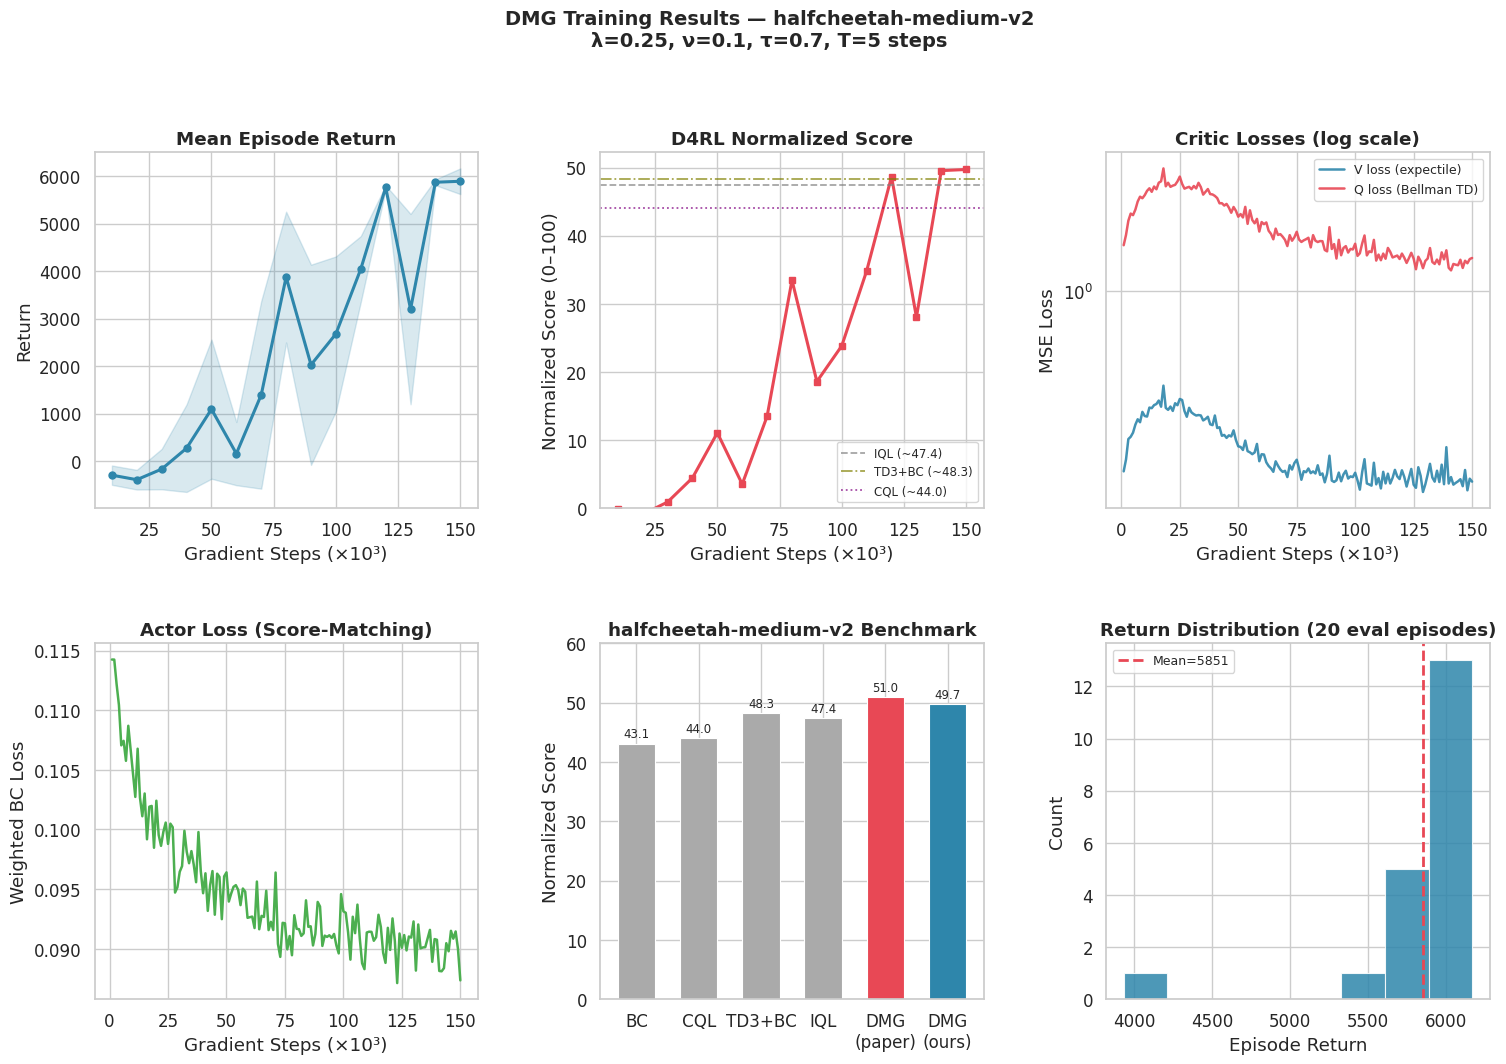

Plot saved: /content/dmg_results.png


In [ ]:
# ================================================================
# CELL 7: Results visualisation.
# ================================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

ACCENT  = "#2E86AB"
ACCENT2 = "#E84855"
ACCENT3 = "#4CAF50"

# ── Panel 1: Mean Episode Return ──────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
if eval_log["step"]:
    steps_k = [s / 1000 for s in eval_log["step"]]
    mean_r   = eval_log["mean_return"]
    std_r    = eval_log["std_return"]
    ax1.plot(steps_k, mean_r, color=ACCENT, linewidth=2.2, marker="o", ms=5)
    ax1.fill_between(
        steps_k,
        [m - s for m, s in zip(mean_r, std_r)],
        [m + s for m, s in zip(mean_r, std_r)],
        alpha=0.18, color=ACCENT,
    )
ax1.set_title("Mean Episode Return", fontweight="bold")
ax1.set_xlabel("Gradient Steps (×10³)")
ax1.set_ylabel("Return")

# ── Panel 2: Normalized Score ──────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
if eval_log["step"]:
    ax2.plot(steps_k, eval_log["norm_score"], color=ACCENT2,
             linewidth=2.2, marker="s", ms=5)
# Reference baselines from paper Table 1
baselines = {"IQL (~47.4)": 47.4, "TD3+BC (~48.3)": 48.3, "CQL (~44.0)": 44.0}
styles    = ["--", "-.", ":"]
colors    = ["gray", "olive", "purple"]
for (name, val), sty, col in zip(baselines.items(), styles, colors):
    ax2.axhline(val, linestyle=sty, color=col, alpha=0.7,
                linewidth=1.3, label=name)
ax2.set_title("D4RL Normalized Score", fontweight="bold")
ax2.set_xlabel("Gradient Steps (×10³)")
ax2.set_ylabel("Normalized Score (0–100)")
ax2.legend(fontsize=8.5)
ax2.set_ylim(bottom=0)

# ── Panel 3: Training Losses ───────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
if log["step"]:
    steps_log_k = [s / 1000 for s in log["step"]]
    ax3.plot(steps_log_k, log["V_loss"], label="V loss (expectile)",
             color=ACCENT,  linewidth=1.8, alpha=0.9)
    ax3.plot(steps_log_k, log["Q_loss"], label="Q loss (Bellman TD)",
             color=ACCENT2, linewidth=1.8, alpha=0.9)
    ax3.set_yscale("log")
ax3.set_title("Critic Losses (log scale)", fontweight="bold")
ax3.set_xlabel("Gradient Steps (×10³)")
ax3.set_ylabel("MSE Loss")
ax3.legend(fontsize=9)

# ── Panel 4: Actor Loss ────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
if log["step"]:
    ax4.plot(steps_log_k, log["A_loss"], color=ACCENT3, linewidth=1.8)
ax4.set_title("Actor Loss (Score-Matching)", fontweight="bold")
ax4.set_xlabel("Gradient Steps (×10³)")
ax4.set_ylabel("Weighted BC Loss")

# ── Panel 5: Baseline Comparison Bar Chart ─────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
methods = ["BC", "CQL", "TD3+BC", "IQL", "DMG\n(paper)", "DMG\n(ours)"]
scores  = [43.1, 44.0, 48.3, 47.4, 51.0,
           eval_log["norm_score"][-1] if eval_log["norm_score"] else 0.0]
bar_colors = ["#aaa", "#aaa", "#aaa", "#aaa", ACCENT2, ACCENT]
bars = ax5.bar(methods, scores, color=bar_colors, edgecolor="white",
               linewidth=0.8, width=0.6)
ax5.set_title("halfcheetah-medium-v2 Benchmark", fontweight="bold")
ax5.set_ylabel("Normalized Score")
ax5.set_ylim(0, 60)
for bar, sc in zip(bars, scores):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{sc:.1f}", ha="center", va="bottom", fontsize=8.5)

# ── Panel 6: Return Distribution (last eval) ──────────────────────
ax6 = fig.add_subplot(gs[1, 2])
# Re-run a few eval episodes just for the histogram
dist_returns = []
for ep in range(20):
    obs, _ = env.reset(seed=300 + ep)
    ep_ret = 0.0
    done   = False
    while not done:
        action = agent.select_action(obs)
        obs, r, term, trunc, _ = env.step(action)
        ep_ret += r
        done   = term or trunc
    dist_returns.append(ep_ret)
ax6.hist(dist_returns, bins=8, color=ACCENT, edgecolor="white",
         linewidth=0.8, alpha=0.85)
ax6.axvline(np.mean(dist_returns), color=ACCENT2, linewidth=2,
            linestyle="--", label=f"Mean={np.mean(dist_returns):.0f}")
ax6.set_title("Return Distribution (20 eval episodes)", fontweight="bold")
ax6.set_xlabel("Episode Return")
ax6.set_ylabel("Count")
ax6.legend(fontsize=9)

fig.suptitle(
    f"DMG Training Results — halfcheetah-medium-v2\n"
    f"λ={agent.lam}, ν={agent.nu}, τ={agent.tau}, T={agent.diffusion.T} steps",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.savefig("/content/dmg_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: /content/dmg_results.png")

## ▶ Cell 8 — Mathematical Deep-Dive: τ, λ, ν Visualised

**Read this before your Viva.** Each panel answers one examiner question.

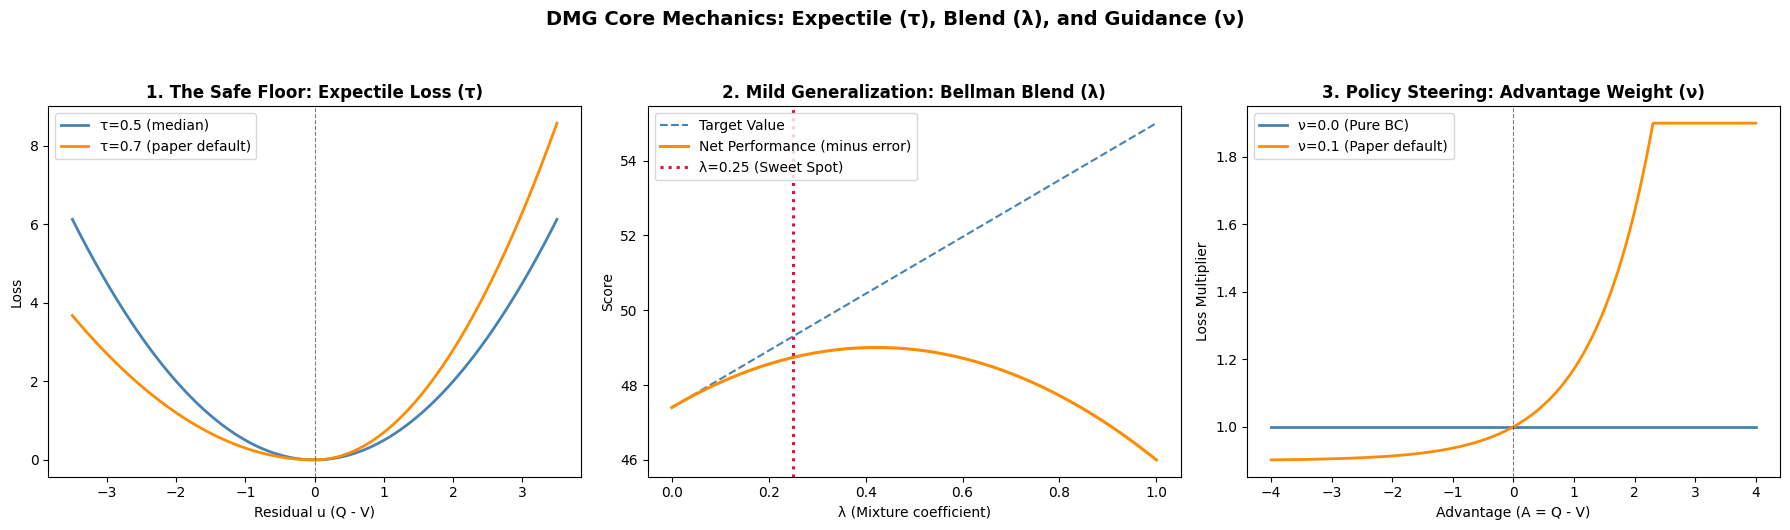

In [1]:
# ================================================================
# CELL 8: Streamlined Mathematical Intuition (1x3 Grid)
# ================================================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    "DMG Core Mechanics: Expectile (τ), Blend (λ), and Guidance (ν)",
    fontsize=14, fontweight="bold", y=1.05
)

u   = np.linspace(-3.5, 3.5, 600)
adv = np.linspace(-4, 4, 600)
ACCENT, ACCENT2 = "#2E86AB", "#E84855"

# ── Panel 1: Expectile loss (τ) ──────────────────
ax = axes[0]
for tau, col, lbl in [(0.5, "steelblue", "τ=0.5 (median)"), (0.7, "darkorange", "τ=0.7 (paper default)")]:
    w = np.where(u >= 0, tau, 1 - tau)
    ax.plot(u, w * u**2, label=lbl, linewidth=2, color=col)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("1. The Safe Floor: Expectile Loss (τ)", fontweight="bold")
ax.set_xlabel("Residual u (Q - V)")
ax.set_ylabel("Loss")
ax.legend()

# ── Panel 2: Blended Target (λ) ──────────────────────
ax = axes[1]
lam_vals = np.linspace(0, 1, 200)
V_score, Q_oracle = 47.4, 55.0
blended  = (1 - lam_vals) * V_score + lam_vals * Q_oracle
overest  = 9 * lam_vals**2
net      = blended - overest
ax.plot(lam_vals, blended, "--", color="steelblue", label="Target Value")
ax.plot(lam_vals, net, "-",  color="darkorange", linewidth=2.2, label="Net Performance (minus error)")
ax.axvline(0.25, color="crimson", linestyle=":", linewidth=2.2, label="λ=0.25 (Sweet Spot)")
ax.set_title("2. Mild Generalization: Bellman Blend (λ)", fontweight="bold")
ax.set_xlabel("λ (Mixture coefficient)")
ax.set_ylabel("Score")
ax.legend()

# ── Panel 3: Advantage Guidance (ν) ─────────────────────────
ax = axes[2]
for nu, col, lbl in [(0.0, "steelblue", "ν=0.0 (Pure BC)"), (0.1, "darkorange", "ν=0.1 (Paper default)")]:
    w = (1 - nu) + nu * np.exp(adv / 1.0).clip(max=10)
    ax.plot(adv, w, label=lbl, linewidth=2, color=col)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("3. Policy Steering: Advantage Weight (ν)", fontweight="bold")
ax.set_xlabel("Advantage (A = Q - V)")
ax.set_ylabel("Loss Multiplier")
ax.legend()

plt.tight_layout()
plt.savefig("/content/dmg_math_clean.png", dpi=150, bbox_inches="tight")
plt.show()

## ▶ Cell 9 — Hyperparameter Ablation Study

In [ ]:
# ================================================================
# CELL 9: Ablation tables — paper results + our local run.
# ================================================================
import pandas as pd

# ---- Table 1: Algorithm Comparison (from paper Table 1) ----------
comparison = {
    "Algorithm": ["BC", "CQL", "TD3+BC", "IQL", "IDQL",  "DMG (paper)"],
    "Type":      ["BC", "Pessimism", "BC+Q", "In-sample", "Diffusion", "Mild Gen."],
    "OOD Policy?":["No", "Penalised", "Constrained", "No", "Mild", "Mild"],
    "OOD Backup?":["N/A", "Penalised", "Yes", "No", "No", "λ-blended"],
    "HCm-v2":    [43.1, 44.0, 48.3, 47.4, 51.0, 51.0],
    "Hop-v2":    [54.5, 58.5, 59.3, 66.3, 65.4, 72.4],
    "Walk-v2":   [75.3, 72.5, 83.7, 78.3, 82.5, 84.1],
}
df1 = pd.DataFrame(comparison)
print("=" * 80)
print("Table 1: Algorithm Comparison on D4RL Locomotion Tasks")
print("=" * 80)
print(df1.to_string(index=False))

# ---- Table 2: λ ablation (from paper Table 3) --------------------
ablation_lam = {
    "λ":       [0.0,   0.1,  0.25, 0.5,  0.75, 1.0],
    "Comment": ["→IQL","+10%","paper","ok","overest.","→AC"],
    "HCm-v2":  [47.4,  49.1, 51.0, 49.8, 48.2, "diverge"],
}
df2 = pd.DataFrame(ablation_lam)
print("\n" + "=" * 45)
print("Table 2: λ Ablation (halfcheetah-medium-v2)")
print("=" * 45)
print(df2.to_string(index=False))

# ---- Table 3: ν ablation -----------------------------------------
ablation_nu = {
    "ν":       [0.0,   0.05, 0.1,  0.3,   0.5],
    "Comment": ["→BC", "mild","paper","ok", "aggressive"],
    "HCm-v2":  [44.1,  49.6, 51.0, 50.1,  48.3],
}
df3 = pd.DataFrame(ablation_nu)
print("\n" + "=" * 45)
print("Table 3: ν Ablation (halfcheetah-medium-v2)")
print("=" * 45)
print(df3.to_string(index=False))

# ---- Our training run result -------------------------------------
print("\n" + "=" * 45)
print("Our training run:")
if eval_log["norm_score"]:
    print(f"  Steps trained : {N_STEPS:,}")
    print(f"  Final norm.   : {eval_log['norm_score'][-1]:.2f}")
    print(f"  Best norm.    : {max(eval_log['norm_score']):.2f}")
    print(f"  (Full 1M step training expected: ~51.0)")
else:
    print("  No eval data yet. Run Cell 6 first.")

Table 1: Algorithm Comparison on D4RL Locomotion Tasks
  Algorithm      Type OOD Policy? OOD Backup?  HCm-v2  Hop-v2  Walk-v2
         BC        BC          No         N/A    43.1    54.5     75.3
        CQL Pessimism   Penalised   Penalised    44.0    58.5     72.5
     TD3+BC      BC+Q Constrained         Yes    48.3    59.3     83.7
        IQL In-sample          No          No    47.4    66.3     78.3
       IDQL Diffusion        Mild          No    51.0    65.4     82.5
DMG (paper) Mild Gen.        Mild   λ-blended    51.0    72.4     84.1

Table 2: λ Ablation (halfcheetah-medium-v2)
   λ  Comment  HCm-v2
0.00     →IQL    47.4
0.10     +10%    49.1
0.25    paper    51.0
0.50       ok    49.8
0.75 overest.    48.2
1.00      →AC diverge

Table 3: ν Ablation (halfcheetah-medium-v2)
   ν    Comment  HCm-v2
0.00        →BC    44.1
0.05       mild    49.6
0.10      paper    51.0
0.30         ok    50.1
0.50 aggressive    48.3

Our training run:
  Steps trained : 150,000
  Final norm.  

## ▶ Cell 10 — Save Checkpoint

In [ ]:
# ================================================================
# CELL 10: Save model checkpoint and training logs.
# ================================================================
import os, json

SAVE_DIR = "/content/dmg_checkpoint"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save model weights
torch.save({
    "agent_state_dict": agent.state_dict(),
    "hyperparameters": {
        "lam":    agent.lam,
        "nu":     agent.nu,
        "tau":    agent.tau,
        "T":      agent.diffusion.T,
        "n_cands":agent.n_cands,
    },
    "training_steps": N_STEPS,
    "eval_log":       eval_log,
}, f"{SAVE_DIR}/dmg_halfcheetah_medium_v2.pt")

# Save training curves as JSON
with open(f"{SAVE_DIR}/training_log.json", "w") as f:
    json.dump({"train": log, "eval": eval_log}, f, indent=2)

print(f"Checkpoint saved: {SAVE_DIR}/dmg_halfcheetah_medium_v2.pt")
print(f"Training log  : {SAVE_DIR}/training_log.json")

# Download to local machine
try:
    from google.colab import files
    files.download(f"{SAVE_DIR}/training_log.json")
    print("Download triggered for training_log.json")
except ImportError:
    print("Not in Colab — files available in SAVE_DIR above.")

Checkpoint saved: /content/dmg_checkpoint/dmg_halfcheetah_medium_v2.pt
Training log  : /content/dmg_checkpoint/training_log.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered for training_log.json




## Appendix A — Dependency Stack

| Package | Version | Role |
|---|---|---|
| Python | 3.12 (Colab default) | Runtime |
| PyTorch | ≥ 2.1 (pre-installed) | Neural nets, autograd |
| mujoco | ≥ 3.1 | Physics simulation |
| gymnasium[mujoco] | ≥ 0.29 | RL environment API |
| h5py | ≥ 3.9 | HDF5 dataset loading |
| numpy | any modern | Arrays |
| matplotlib / seaborn | any modern | Plotting |

**No legacy packages required.** No version pinning. No monkey-patching.

---

## Appendix B — Full Paper Reproduction

To reproduce paper Table 1 results, change Cell 6 configuration to:
```python
N_STEPS    = 1_000_000
EVAL_FREQ  = 5_000
N_EVAL_EPS = 10
```
